In [1]:
# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm

import math
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from torch.utils.data import DataLoader

from sklearn.metrics import r2_score, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from typing import List, Dict, Tuple, Optional

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00


In [2]:
# -----------------------
# 1) Reproducibility
# -----------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [4]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://aflow.org/API/aflux/"  # placeholder

SELECT = ",".join([
    "compound",
    "auid",
    "positions_fractional",
    "lattice_vectors",
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
    "agl_thermal_conductivity_300K",
])

PER_PAGE = 500
MAX_PAGES = 2000

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]



In [5]:

KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
VAL_RATIO = 0.1
HIDDEN = 128
DEPTH = 3


In [6]:
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "ael_debye_temperature(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cp_300K(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "agl_vibrational_entropy_300K_atom(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 1000
MAX_PAGES = 10   # safety cap: 300k entries max; adjust if needed

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [7]:
def fetch_page(page: int):
    """
    Fetch ONE page of AFLOW entries using aflux paging.

    Parameters
    ----------
    page : int
        Page index (1-based).

    Returns
    -------
    rows : list[dict]
        A list of AFLOW entries (JSON objects).
    url : str
        The exact URL used (for debugging / reproducibility).
    """
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"

    r = session.get(url, timeout=120)
    r.raise_for_status()          # HTTP-level errors (404 / 500 / etc.)

    data = r.json()               # <-- AFLOW returns a LIST here
    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}"
        )

    return data, url

In [8]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [9]:
df = fetch_all_aflow()


Paging AFLOW:  60%|██████    | 6/10 [00:06<00:04,  1.03s/it]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),ael_debye_temperature(*),agl_debye(*),agl_acoustic_debye(*),agl_gruneisen(*),agl_heat_capacity_Cp_300K(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),agl_vibrational_entropy_300K_atom(*),positions_fractional(*),geometry(*),$format(json),$paging(7,1000)


In [10]:
# -----------------------
# 3) Kappa Distribution Analysis
# -----------------------

import numpy as np
import matplotlib.pyplot as plt

TARGET = "agl_thermal_conductivity_300K"

# ---- extract kappa ----
kappa = df[TARGET].dropna().values

# remove non-positive values (important for log)
kappa = kappa[kappa > 0]

print("Number of samples:", len(kappa))

# ---- basic statistics ----
print("\n=== Raw kappa statistics ===")
print("min:", np.min(kappa))
print("max:", np.max(kappa))
print("mean:", np.mean(kappa))
print("median:", np.median(kappa))
print("std:", np.std(kappa))

# ---- log transform ----
log_kappa = np.log1p(kappa)

print("\n=== log(1+kappa) statistics ===")
print("min:", np.min(log_kappa))
print("max:", np.max(log_kappa))
print("mean:", np.mean(log_kappa))
print("median:", np.median(log_kappa))
print("std:", np.std(log_kappa))

Number of samples: 5553

=== Raw kappa statistics ===
min: 0.00988102
max: 419.731
mean: 7.726604237352783
median: 3.80828
std: 15.317930537845585

=== log(1+kappa) statistics ===
min: 0.009832521933771822
max: 6.041993674594365
mean: 1.6847794793320978
median: 1.5703394318101191
std: 0.8666009224653972


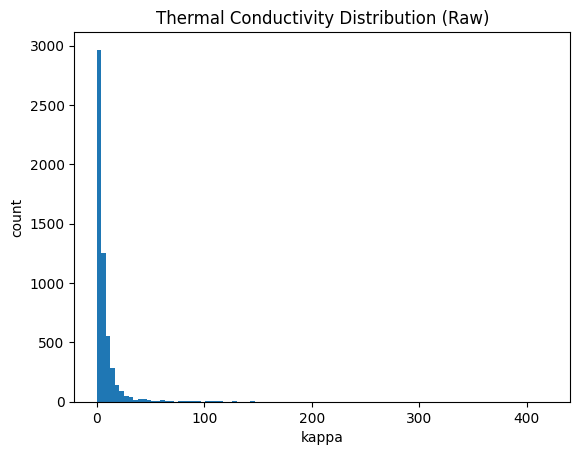

In [11]:
plt.figure()
plt.hist(kappa, bins=100)
plt.xlabel("kappa")
plt.ylabel("count")
plt.title("Thermal Conductivity Distribution (Raw)")
plt.show()

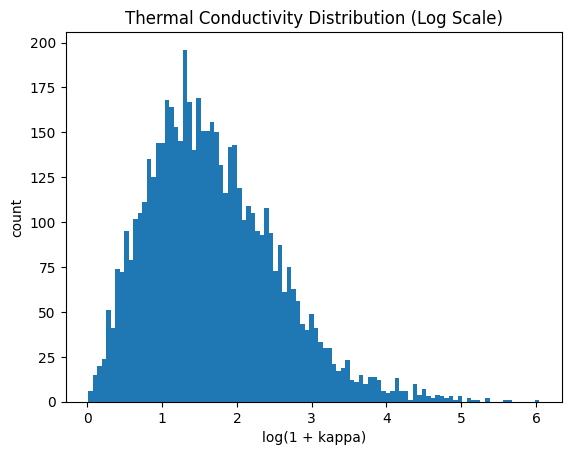

In [12]:
plt.figure()
plt.hist(log_kappa, bins=100)
plt.xlabel("log(1 + kappa)")
plt.ylabel("count")
plt.title("Thermal Conductivity Distribution (Log Scale)")
plt.show()

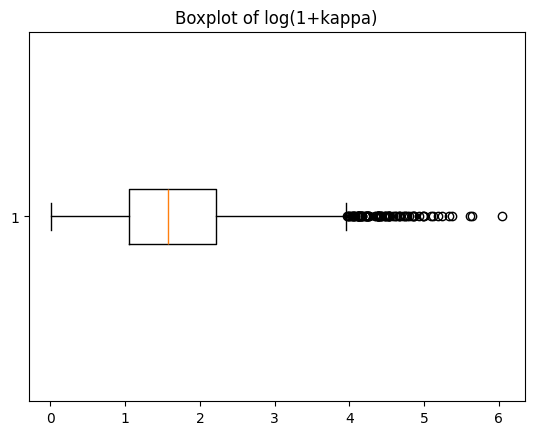

In [13]:
plt.figure()
plt.boxplot(log_kappa, vert=False)
plt.title("Boxplot of log(1+kappa)")
plt.show()